# 05b — Scaling the Surprise Strategy: CPI Only vs CPI + Other Macro Surprises (ES) — ZN

## Purpose

Notebook 04 showed that trading ES in the direction of the **CPI surprise** earns a net Sharpe of about 1.0, but only about **7–11 trades a year**. The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES**.

This notebook asks:

> **If we trade the surprises of many US macro releases, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

The final section compares **CPI only** against **CPI + other surprises** on trades per year, P&L, return, Sharpe, drawdown, hit rate and costs.

**Scope:** ES only, so the comparison with the peer ES strategy is like for like.

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan** (`blackrock-intraday/jack/strategy_proposal.md`). The 5σ winsorisation of surprises comes from **Aaryen Mehta**. The causal surprise standardisation, the executable entry and the walk-forward engine come from this project (Notebooks 01–04).

> **05b — 10-year T-note futures (ZN).** This notebook is Notebook 05 (ES) run on **ZN**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_ZN.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **ZN** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the ZN contract (tick 1/64, $1,000 per point).
> - Outputs are saved as `nb05b_ZN_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the ZN results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Read every US release in the Bloomberg workbook and group lines into release **families** |
| 3 | Causal, winsorised surprise for every line |
| 4 | ES price measures at every release: jump, tradeable 30-min drift, second 30 min, 4-hour volatility |
| 5 | Validation: the CPI trades must reproduce Notebook 04 |
| 6 | **Impact screen**: each year, admit the 10 families the market reacts to most (history only) |
| 7 | Direction: line signs from the jump regression (history only), then family signals |
| 8 | Strategies: CPI only vs all admitted families; flat, surprise-model and volatility sizing; one vs two windows |
| 9 | Performance, per-family results, robustness (periods, costs, random-sign null) |
| 10 | **Final comparison: CPI only vs CPI + other surprises** |

## Methodology: fixed before looking at results

1. **Entry and exit as in Notebook 04.** Entry at the close of the first post-release bar (about 1 minute after the release, "T+1"), exit 30 minutes after the release. The instant jump is **never** traded.
2. **Release families.** Bloomberg lines that print at the same instant (CPI MoM, Core CPI MoM, CPI YoY and so on) are one release. Lines sharing ≥80% of their timestamps form one family.
3. **Surprise.** $z = (\text{actual} - \text{consensus}) / \text{sd of the line's previous surprises}$, with at least 24 prior releases, capped at ±5σ.
4. **Universe (impact screen).** At the start of each year, using **only earlier data**:
   $$\text{impact}_f = \frac{\text{mean}\,|\text{30-min move}| \text{ on } f\text{'s releases}}{\text{mean}\,|\text{30-min move}| \text{ at the same clock time when another family releases}}$$
   The top **K = 10** families are admitted for that year. No P&L is used.
5. **Direction.** Each line's sign comes from regressing the **instant jump** on its surprise over earlier years, which avoids any drift P&L. The family signal is $x = \text{mean}(\text{sign} \times z)$, so $x>0$ always means *good news for ES*.
6. **Three sizing rules:**
   - **Naive:** one unit in the direction of $x$.
   - **Surprise model:** $\hat r = \hat b_f\,x$, re-fitted on the family's earlier releases; trade only if $|\hat r|$ exceeds the cost.
   - **Signal × volatility (Jack):** position ∝ clip($x$, ±3) × 4-hour volatility / its historical median, normalised to about 1 unit on average.
7. **Costs** are the same as Notebook 04: 2 ticks round trip plus $4.50 commission per contract.
8. **Evaluation** covers 2019–2026, the same window as Notebook 04. 2016–2018 is history only.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "ZN"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
NB04_LOG = RESULTS_DIR / f"nb04b_{MARKET}_trade_log.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
for m in (sc, wf, su):
    importlib.reload(m)

for f in [BBG_FILE, MARKET_FILE, NB04_LOG]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
futures_1min_clean_v3_ZN.parquet         exists: True
nb04b_ZN_trade_log.csv                   exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = ZN | file: futures_1min_clean_v3_ZN.parquet (exists: True) | tick 0.015625, $1000 per point | cost 2 ticks + $4.50 = 0.0357 points per round trip


### 1.1 Pre-registered parameters

In [3]:
HIST_START = "2016-01-01"      # history used for screens, signs and model fits
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
K_FAMILIES = 10                # families admitted each year (Jack's specification)
MIN_TRAIN = 24                 # earlier releases needed before a family is modelled
TICKS_RT, COMMISSION_RT = 2.0, 4.5
THRESHOLD = 1.0                # surprise model trades if |E[r]| > 1 x cost
N_NULL, N_BOOT = 1000, 5000
CPI = "CPI"
PRIMARY_TARGET = "w1"          # T+1 -> T+30, the Notebook 04 window
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
print(f"Evaluation {EVAL_START} to {EVAL_END} ({N_YEARS:.2f} years), K = {K_FAMILIES}")

Evaluation 2019-01-01 to 2026-06-30 (7.49 years), K = 10


## 2. US Releases and Release Families

In [4]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
print(f"Release rows: {len(rows):,}  |  lines (tickers): {rows['ticker'].nunique()}  |  read in {time.time()-t0:.0f}s")
print("Range:", rows["ts_et"].min(), "to", rows["ts_et"].max())

fam = su.build_families(rows)
print(f"\nLines with >= 30 releases since 2013: {len(fam)}  ->  families: {fam['family'].nunique()}")
fam_summary = (fam.groupby("family")
                  .agg(lines=("ticker", "size"), clock=("clock_et", lambda s: s.mode().iat[0]),
                       releases=("n_releases", "max"),
                       example_lines=("event_name", lambda s: "; ".join(list(s)[:4])))
                  .sort_values("lines", ascending=False))
display(fam_summary.head(25))

Release rows: 27,137  |  lines (tickers): 179  |  read in 1s
Range: 2010-01-04 10:00:00-05:00 to 2026-07-17 10:00:00-04:00

Lines with >= 30 releases since 2013: 143  ->  families: 75


,lines,clock,releases,example_lines
family,,,,
Employment Report (NFP),10,08:30,162,Average Hourly Earnings MoM; Average Hourly Ea...
CPI,8,08:30,162,CPI MoM; Core CPI YoY; CPI YoY; Core CPI Index SA
Personal Income / PCE,7,08:30,160,Real Personal Spending; Core PCE Price Index M...
PPI,6,08:30,149,PPI Final Demand MoM; PPI Ex Food and Energy M...
U. of Michigan Sentiment,5,10:00,325,U. of Mich. Current Conditions; U. of Mich. Ex...
Durable Goods,4,08:30,290,Cap Goods Orders Nondef Ex Air; Cap Goods Ship...
Housing Starts,4,08:30,176,Building Permits MoM; Housing Starts MoM; Buil...
GDP,4,08:30,160,GDP Annualized QoQ; GDP Price Index; Core PCE ...
Retail Sales,4,08:30,163,Retail Sales Advance MoM; Retail Sales Ex Auto...


**Check.** CPI MoM, Core CPI MoM, CPI YoY and the CPI index lines should form one **CPI** family. Payrolls, the unemployment rate and hourly earnings should form one **Employment Report** family. Each is one print, so each is one trade.

## 3. Causal Surprises

In [5]:
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"Surprise rows with a consensus: {len(surp):,}  |  with a causal z-score: {surp['z'].notna().sum():,}")
print(f"Share capped at +/-5 sigma: {(surp['z'].abs() >= 5).mean():.2%}")
display(surp.merge(fam[["ticker", "family"]], on="ticker")
            .query("family == @CPI")[["ts_et", "event_name", "survey_median", "actual", "raw", "z"]].tail(8))

Surprise rows with a consensus: 20,365  |  with a causal z-score: 17,328
Share capped at +/-5 sigma: 0.47%


,ts_et,event_name,survey_median,actual,raw,z
4700,2026-01-13 08:30:00-05:00,CPI Index NSA,324.168,324.054,-0.115,-0.422
4701,2026-02-13 08:30:00-05:00,CPI Index NSA,325.514,325.252,-0.262,-0.968
4702,2026-03-11 08:30:00-04:00,CPI Index NSA,326.762,326.785,0.024,0.087
4703,2026-04-10 08:30:00-04:00,CPI Index NSA,330.555,330.213,-0.342,-1.267
4704,2026-05-12 08:30:00-04:00,CPI Index NSA,332.690,333.020,0.330,1.220
4705,2026-06-10 08:30:00-04:00,CPI Index NSA,335.143,335.123,-0.020,-0.074
4706,2026-07-14 08:30:00-04:00,CPI Index NSA,334.698,333.952,-0.746,-2.762
17061,2019-01-11 08:30:00-05:00,Real Avg Weekly Earnings YoY,1.200,1.184,-0.016,NaN


## 4. ES Price Measures at Every Release

In [6]:
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)
ts_all = rows.loc[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC"), "ts_utc"].unique()
px = su.price_measures(es_adj, ts_all)
px["cost_bps"] = su.cost_bps(px["pre_close"], TICKS_RT, COMMISSION_RT, TICK, MULT)
print(f"Release timestamps since {HIST_START}: {len(px):,}  |  with a 30-min trade return: {px['w1'].notna().sum():,}")
display(px.describe().T[["count", "mean", "std", "min", "50%", "max"]])

Release timestamps since 2016-01-01: 6,097  |  with a 30-min trade return: 5,878


,count,mean,std,min,50%,max
jump,"5,881.000",-0.183,7.445,-78.586,0.000,93.549
w1,"5,878.000",-0.067,8.553,-47.232,0.000,77.684
w2,"5,875.000",0.080,6.992,-50.864,0.000,61.071
react30,"5,878.000",-0.250,11.601,-123.771,0.000,119.325
vol_4h,"5,881.000",1.243,0.467,0.652,1.121,6.602
pre_close,"5,881.000",122.028,9.463,105.500,122.156,140.297
cost_bps,"5,881.000",2.947,0.227,2.548,2.927,3.389


## 5. Validation: Do the CPI Trades Reproduce Notebook 04?

In [7]:
nb04 = pd.read_csv(NB04_LOG)
nb04["timestamp_utc"] = pd.to_datetime(nb04["timestamp_utc"], utc=True)
nb04_cpi = nb04[(nb04["strategy"] == "Naive sign") & (nb04["event_type"] == "CPI") & nb04["eligible"]]
chk = nb04_cpi.merge(px, left_on="timestamp_utc", right_on="ts_utc", how="inner")
gap = (chk["ret_bps"] - chk["w1"]).abs()
print(f"NB04 CPI trades: {len(nb04_cpi)}  |  matched release timestamps: {len(chk)}")
print(f"Max |NB04 trade return - NB05 w1| = {gap.max():.2e} bps")
if len(chk) < len(nb04_cpi):
    print(f"WARNING: {len(nb04_cpi) - len(chk)} NB04 CPI timestamps are not in the Bloomberg calendar")
assert gap.max() < 1e-6, f"Trade returns differ from Notebook 04: check the {MARKET} file and bar convention"
print("PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release")

NB04 CPI trades: 86  |  matched release timestamps: 86
Max |NB04 trade return - NB05 w1| = 3.55e-15 bps
PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release


## 6. Impact Screen: Which Families Does the Market React To?

Computed once per year from history only. The admitted list can change from year to year.

In [8]:
screens = {}
for y in EVAL_YEARS:
    screens[y] = su.impact_screen(rows, fam, px, HIST_START, f"{y}-01-01")
admit = pd.DataFrame({y: screens[y].set_index("family")["rank"] for y in EVAL_YEARS})
admitted_any = admit[(admit <= K_FAMILIES).any(axis=1)]
print(f"Families ranked each year: {[len(screens[y]) for y in EVAL_YEARS]}")
print(f"\nRank of every family that is admitted (top {K_FAMILIES}) in at least one year:")
display(admitted_any.sort_values(EVAL_YEARS[-1]).astype("Int64"))
print(f"\nScreen used for {EVAL_YEARS[0]} (history {HIST_START} to {EVAL_YEARS[0]-1}):")
display(screens[EVAL_YEARS[0]].head(15))
admit.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_impact_rank_by_year.csv")

Families ranked each year: [32, 39, 39, 39, 40, 42, 43, 46]

Rank of every family that is admitted (top 10) in at least one year:


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
FOMC Rate Decision,<NA>,1,1,1,1,1,1,1
ISM Services Prices Paid,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2
Employment Report (NFP),1,2,2,2,3,3,3,3
CPI,3,6,6,5,2,2,2,4
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,5,4,4,5
ISM Services,4,5,5,4,6,6,5,6
ISM New Orders,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7
ISM Manufacturing,<NA>,3,3,3,4,5,6,8
S&P Global US Manufacturing PMI,10,8,8,8,8,7,7,9



Screen used for 2019 (history 2016-01-01 to 2018):


,family,clock,n,n_control,impact,t,survey_share,rank
0,Employment Report (NFP),08:30,35,393,2.481,3.725,1.000,1
1,Retail Sales,08:30,35,393,2.369,4.120,1.000,2
2,CPI,08:30,35,393,2.227,3.590,1.000,3
3,ISM Services,10:00,36,403,1.886,2.813,1.000,4
4,Trade Balance,08:30,36,392,1.793,2.181,1.000,5
5,Business Inventories,10:00,35,404,1.306,2.170,1.000,6
6,U. of Michigan Sentiment,10:00,69,370,1.242,1.962,1.000,7
7,Empire Manufacturing,08:30,36,392,1.215,1.096,1.000,8
8,Factory Orders,10:00,36,403,1.167,1.027,1.000,9
9,S&P Global US Manufacturing PMI,09:45,62,207,1.153,1.087,1.000,10


**How to read it.** An impact of 1.3 means the ES reaction to this family is 30% larger than at the same clock time when a different release is out. Only the top 10 each year are traded. CPI should rank near the top in every year.

## 7. Direction: Line Signs and Family Signals

In [9]:
signs, hist = {}, {}
admitted = {y: set(screens[y].head(K_FAMILIES)["family"]) for y in EVAL_YEARS}
for y in EVAL_YEARS:
    signs[y] = su.line_signs(surp, px, HIST_START, f"{y}-01-01")
    fams_y = admitted[y] | {CPI}
    # training panel for the surprise model: releases before the end of year y
    hist[y] = su.history_panel(surp, fam, px, fams_y, signs[y], HIST_START, f"{y+1}-01-01")

screen_plus_cpi = {y: pd.DataFrame({"family": sorted(admitted[y] | {CPI})}) for y in EVAL_YEARS}
panel = su.family_signal_panel(surp, fam, px, screen_plus_cpi, signs, EVAL_YEARS)
panel["year"] = panel["ts_utc"].dt.tz_convert("America/New_York").dt.year
panel["admitted"] = [f in admitted[y] for f, y in zip(panel["family"], panel["year"])]
panel = panel[(panel["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) &
              (panel["ts_utc"] <= pd.Timestamp(EVAL_END, tz="UTC"))]
print(f"Family-release rows in the evaluation period: {len(panel):,}  (admitted: {panel['admitted'].sum():,})")

cpi_signs = signs[EVAL_YEARS[0]][signs[EVAL_YEARS[0]].index.isin(fam.loc[fam['family'] == CPI, 'ticker'])]
print(f"\nCPI line signs (history to 2018): -1 means a hot print has pushed {MARKET} down")
display(cpi_signs.to_frame().join(fam.set_index("ticker")["event_name"]))

# sanity: the signed family signal should be positively related to the instant jump
sanity = panel.groupby("family").apply(lambda g: g["x"].corr(g["jump"])).rename("corr(x, jump)")
display(sanity.sort_values(ascending=False).to_frame())

Family-release rows in the evaluation period: 748  (admitted: 748)

CPI line signs (history to 2018): -1 means a hot print has pushed ZN down


,sign,event_name
CPI CHNG Index,-1.000,CPI MoM
CPI XYOY Index,-1.000,Core CPI YoY
CPI YOY Index,-1.000,CPI YoY
CPUPAXFE Index,-1.000,Core CPI Index SA
CPUPXCHG Index,-1.000,Core CPI MoM
CPURNSA Index,-1.000,CPI Index NSA


,"corr(x, jump)"
family,
JOLTS,0.805
CPI,0.562
ISM Services,0.520
ISM New Orders,0.459
Empire Manufacturing,0.416
ISM Manufacturing,0.377
FHFA House Price Index MoM,0.326
Retail Sales,0.271
U. of Michigan Sentiment,0.244


**Check.** Because each line is signed so that $x>0$ means good news, the correlation between $x$ and the instant jump should be **positive** for most families, and strongly so for CPI. This is measured in the evaluation period, which the signs never saw.

## 8. Strategies

| Strategy | Families | Sizing | Window |
|---|---|---|---|
| **CPI · naive** | CPI | sign of $x$ | 1 |
| **CPI · surprise model** | CPI | $\hat b x$ vs cost (Notebook 04 style) | 1 |
| CPI · signal × vol | CPI | Jack's sizing | 1 |
| **All · naive** | 10 admitted families (CPI included when admitted) | sign of $x$ | 1 |
| **All · surprise model** | 10 admitted | $\hat b_f x$ vs cost | 1 |
| **All · signal × vol** | 10 admitted | Jack's sizing | 1 |
| **Combined** | CPI + other admitted | CPI surprise model + others signal × vol | 1 |
| All · naive · 2nd window | 10 admitted | sign of $x$ | 2 only (T+30 → T+60) |
| All · signal × vol · 2 windows | 10 admitted | Jack's sizing | 1 and 2 |

Window 1 is T+1 → T+30 (Notebook 04). Window 2 is T+30 → T+60, a pre-registered test of whether a second trade per release (as in the peer strategy) earns anything.

In [10]:
def positions(sub, model, target=PRIMARY_TARGET):
    return su.build_positions(sub, hist, model, target, MIN_TRAIN, THRESHOLD)

cpi_p = panel[panel["family"] == CPI]
all_p = panel[panel["admitted"]]
oth_p = all_p[all_p["family"] != CPI]

P = {
    "CPI · naive": positions(cpi_p, "naive"),
    "CPI · surprise model": positions(cpi_p, "surprise"),
    "CPI · signal × vol": positions(cpi_p, "signal_vol"),
    "All · naive": positions(all_p, "naive"),
    "All · surprise model": positions(all_p, "surprise"),
    "All · signal × vol": positions(all_p, "signal_vol"),
}
P["Combined (CPI model + others × vol)"] = pd.concat([positions(cpi_p, "surprise"), positions(oth_p, "signal_vol")])

T = {name: su.to_trades(p, PRIMARY_TARGET, name) for name, p in P.items()}

# second window
p_nw2 = positions(all_p, "naive", "w2")
T["All · naive · 2nd window"] = su.to_trades(p_nw2, "w2", "All · naive · 2nd window")
t_w1 = su.to_trades(P["All · signal × vol"], "w1", "x")
t_w2 = su.to_trades(P["All · signal × vol"], "w2", "x")
t_w2["timestamp_utc"] = t_w2["timestamp_utc"] + pd.Timedelta(minutes=30)
T["All · signal × vol · 2 windows"] = pd.concat([t_w1, t_w2]).sort_values("timestamp_utc").assign(
    strategy="All · signal × vol · 2 windows").reset_index(drop=True)

STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / f"nb05b_{MARKET}_trade_log.csv", index=False)
display(pd.DataFrame({k: {"release timestamps": len(v), "trades": int((v["position"] != 0).sum())} for k, v in T.items()}).T)

,release timestamps,trades
CPI · naive,89,89
CPI · surprise model,89,1
CPI · signal × vol,89,88
All · naive,677,626
All · surprise model,677,16
All · signal × vol,677,629
Combined (CPI model + others × vol),677,543
All · naive · 2nd window,677,626
All · signal × vol · 2 windows,1354,1258


## 9. Performance

### 9.1 Main metrics (evaluation 2019–2026, net of costs)

In [11]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_cost_bps", "avg_net_bps", "total_net_pct",
       "ann_return_pct", "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf["days_per_year"] = [
    pd.to_datetime(T[s].loc[T[s]["position"] != 0, "timestamp_utc"]).dt.tz_convert("America/New_York").dt.date.nunique() / N_YEARS
    for s in perf.index]
perf.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_performance.csv")
display(perf[["trades_per_year", "days_per_year"] + KEY].round(3))

,trades_per_year,days_per_year,trades,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,,
CPI · naive,11.744,11.877,88,0.352,-0.415,2.984,-3.399,-2.991,-0.399,0.594,-0.082,-0.672,-3.030,-1.840,0.571
CPI · surprise model,0.133,0.133,1,0.000,-13.862,3.171,-17.033,-0.170,-0.023,0.062,-0.365,-0.365,-0.170,NaN,0.000
CPI · signal × vol,11.744,11.744,88,0.352,1.090,3.285,-2.196,-1.932,-0.258,0.874,0.146,-0.295,-2.596,-0.808,0.741
All · naive,81.938,75.666,614,0.362,-0.415,2.931,-3.346,-20.543,-2.739,1.131,-0.298,-2.422,-20.564,-6.378,0.483
All · surprise model,2.135,2.135,16,0.312,-2.089,2.709,-4.798,-0.768,-0.102,0.138,-0.345,-0.744,-0.872,-2.577,0.177
All · signal × vol,83.939,75.532,629,0.355,0.497,2.754,-2.257,-14.196,-1.893,1.705,0.249,-1.110,-14.106,-3.086,0.600
Combined (CPI model + others × vol),72.463,64.189,543,0.354,0.298,2.647,-2.349,-12.755,-1.701,1.364,0.162,-1.247,-12.905,-3.568,0.537
All · naive · 2nd window,81.938,75.666,614,0.296,-0.214,2.931,-3.145,-19.308,-2.574,0.837,-0.215,-3.077,-19.420,-8.298,0.397
All · signal × vol · 2 windows,167.879,75.532,1258,0.326,0.175,2.754,-2.580,-32.453,-4.327,2.144,0.147,-2.018,-32.447,-5.486,0.518


**How to read it.** Compare **CPI · surprise model** (the Notebook 04 strategy) with the **All** rows. The All rows trade far more often. The question is whether `avg_net_bps` and `sharpe_net` stay positive once the weaker releases are added.

### 9.2 Which families earn money?

,naive_trades,naive_hit_rate,naive_avg_net_bps,naive_t_stat,naive_total_net_pct,vol_trades,vol_hit_rate,vol_avg_net_bps,vol_t_stat,vol_total_net_pct
family,,,,,,,,,,
ISM New Orders,4,0.500,3.107,0.729,0.124,4,0.500,-0.385,-0.212,-0.015
FOMC Rate Decision,1,0.000,-0.397,NaN,-0.004,1,0.000,-1.590,NaN,-0.016
FHFA House Price Index MoM,22,0.455,-0.401,-0.343,-0.084,21,0.476,0.645,0.491,0.135
Empire Manufacturing,12,0.250,-2.715,-1.559,-0.326,12,0.250,-1.824,-0.877,-0.219
Business Inventories,11,0.364,-4.243,-1.314,-0.467,11,0.364,-9.346,-1.424,-1.028
JOLTS,12,0.250,-4.525,-1.503,-0.543,12,0.250,-3.376,-1.112,-0.405
Trade Balance,45,0.467,-1.371,-1.295,-0.617,45,0.467,-1.228,-1.667,-0.553
Factory Orders,42,0.262,-2.526,-2.484,-1.036,41,0.268,-2.691,-1.742,-1.103
ISM Services,90,0.411,-1.344,-1.163,-1.209,90,0.411,-0.733,-0.247,-0.660


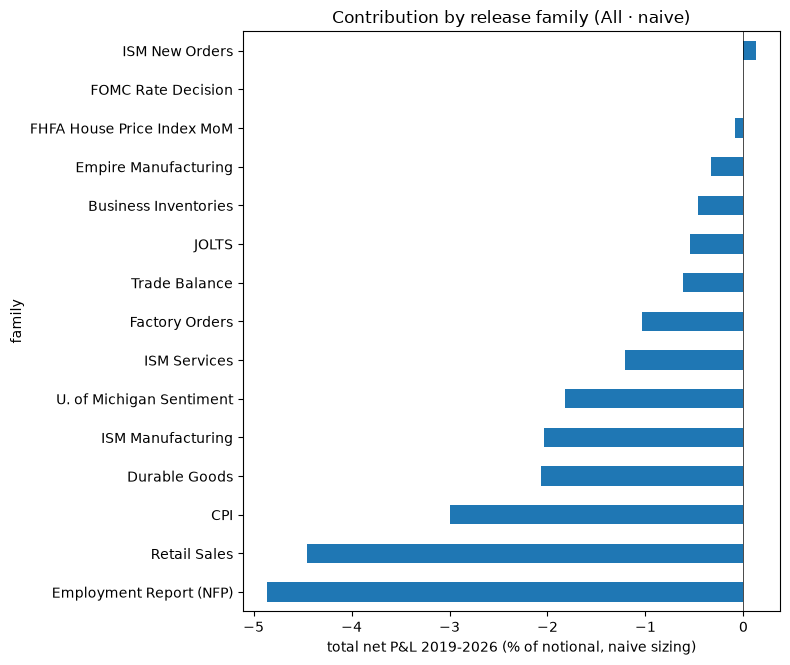

In [12]:
fam_naive = su.per_family_stats(P["All · naive"], PRIMARY_TARGET).add_prefix("naive_")
fam_vol = su.per_family_stats(P["All · signal × vol"], PRIMARY_TARGET).add_prefix("vol_")
fam_tab = fam_naive.join(fam_vol, how="outer").sort_values("naive_total_net_pct", ascending=False)
fam_tab.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_per_family.csv")
display(fam_tab.round(3))

ax = fam_tab["naive_total_net_pct"].sort_values().plot.barh(figsize=(8, 0.35 * len(fam_tab) + 1.5), color="C0")
ax.axvline(0, c="k", lw=0.5); ax.set_xlabel("total net P&L 2019-2026 (% of notional, naive sizing)")
ax.set_title("Contribution by release family (All · naive)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_family_contribution.png", dpi=150); plt.show()

### 9.3 Cumulative P&L

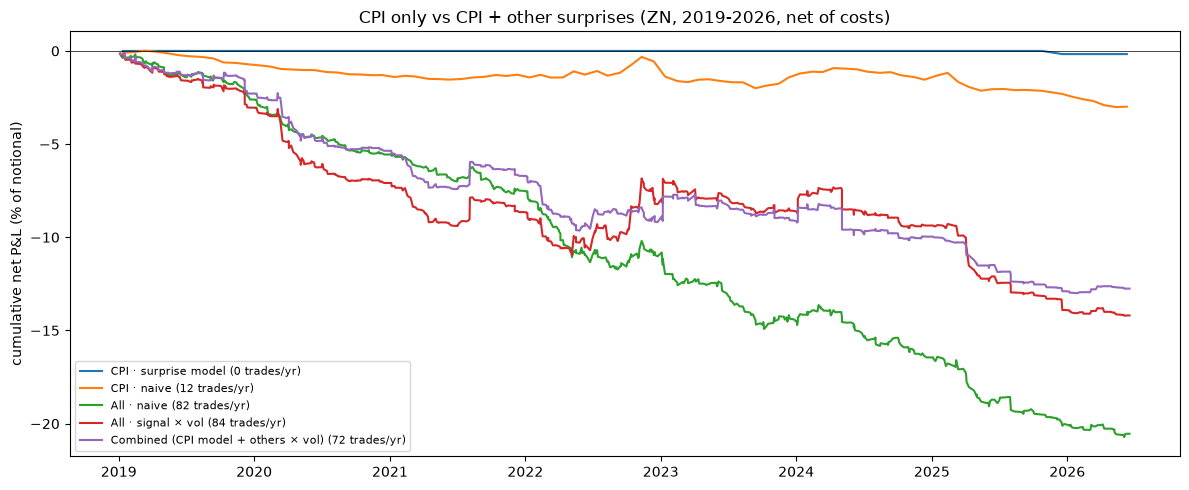

In [13]:
SHOW = ["CPI · surprise model", "CPI · naive", "All · naive", "All · signal × vol", "Combined (CPI model + others × vol)"]
fig, ax = plt.subplots(figsize=(12, 5))
for i, s in enumerate(SHOW):
    cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, label=f"{s} ({perf.loc[s, 'trades_per_year']:.0f} trades/yr)", lw=1.5)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title(f"CPI only vs CPI + other surprises ({MARKET}, 2019-2026, net of costs)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_cumulative_pnl.png", dpi=150); plt.show()

### 9.4 Robustness: sub-periods, 2022, and the random-sign null

In [14]:
def sharpe_months(tr, start, end, drop_year=None):
    m = wf.monthly_returns(tr, start, end)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rob = []
for s in STRATS:
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    (lo, _, hi), _ = wf.bootstrap_sharpe(T[s], EVAL_START, EVAL_END, N_BOOT)
    rob.append(dict(strategy=s, sharpe=obs, ci_5=lo, ci_95=hi,
                    sharpe_2019_21=sharpe_months(T[s], "2019-01-01", "2021-12-31"),
                    sharpe_2022_26=sharpe_months(T[s], "2022-01-01", EVAL_END),
                    sharpe_ex_2022=sharpe_months(T[s], EVAL_START, EVAL_END, drop_year=2022),
                    p_random_sign=p_null))
rob = pd.DataFrame(rob).set_index("strategy")
rob.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_robustness.csv")
display(rob.round(3))

,sharpe,ci_5,ci_95,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign
strategy,,,,,,,
CPI · naive,-0.672,-1.377,0.002,-1.784,-0.512,-1.079,0.580
CPI · surprise model,-0.365,-0.640,-0.365,NaN,-0.471,-0.392,1.000
CPI · signal × vol,-0.295,-1.142,0.332,-1.524,0.017,-1.194,0.334
All · naive,-2.422,-3.175,-1.747,-3.359,-2.174,-2.534,0.812
All · surprise model,-0.744,-1.138,-0.358,-1.023,-0.482,-0.801,0.818
All · signal × vol,-1.110,-1.951,-0.385,-2.151,-0.649,-1.500,0.247
Combined (CPI model + others × vol),-1.247,-2.066,-0.545,-1.824,-0.927,-1.225,0.300
All · naive · 2nd window,-3.077,-4.281,-2.234,-5.776,-2.425,-2.836,0.715
All · signal × vol · 2 windows,-2.018,-3.155,-1.183,-3.466,-1.345,-2.198,0.444


**How to read it.**
- **`p_random_sign`** is the share of random-direction books, with the same trades, sizes and costs, whose Sharpe beats the strategy. Below 0.05 means the *direction* genuinely adds value.
- **`sharpe_ex_2022`** shows how much depends on the 2022 inflation shock.

### 9.5 Transaction costs

In [15]:
cost_rows = []
for ticks in [0, 1, 2, 4]:
    pt = panel.copy()
    pt["cost_bps"] = su.cost_bps(pt["pre_close"], ticks, COMMISSION_RT, TICK, MULT)
    for s, (fams, model) in {"CPI · surprise model": ("cpi", "surprise"), "All · naive": ("all", "naive"),
                             "All · signal × vol": ("all", "signal_vol")}.items():
        sub = pt[pt["family"] == CPI] if fams == "cpi" else pt[pt["admitted"]]
        tr = su.to_trades(su.build_positions(sub, hist, model, PRIMARY_TARGET, MIN_TRAIN, THRESHOLD), PRIMARY_TARGET, s)
        pf = wf.performance(tr, EVAL_START, EVAL_END, s)
        cost_rows.append(dict(ticks_rt=ticks, strategy=s, sharpe_net=pf["sharpe_net"], avg_net_bps=pf["avg_net_bps"], trades=pf["trades"]))
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_cost_sensitivity.csv", index=False)
display(cost_tab.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").round(2))

strategy,All · naive,All · signal × vol,CPI · surprise model
ticks_rt,,,
0,-0.560,0.080,0.050
1,-1.490,-0.520,-0.180
2,-2.420,-1.110,-0.370
4,-4.240,-2.190,0.000


### 9.6 Peer-format metrics (daily, one contract)

In [16]:
daily_close = sc.build_daily_close(es_adj)
days = daily_close.index[(daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))]
bh = wf.buy_hold_daily(daily_close, days)
peer = {s: wf.peer_metrics(wf.daily_returns(T[s], days), bh, trades_per_year=perf.loc[s, "trades_per_year"],
                           minutes_in_market=perf.loc[s, "trades"] * 30 / (len(days) * 23 * 60) * 100) for s in STRATS}
peer = pd.DataFrame(peer).T
peer.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_peer_metrics.csv")
display(peer.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,corr,trades_per_year,time_in_market_pct
CPI · naive,-2.991,0.608,-0.671,-3.030,0.001,0.011,11.744,0.104
CPI · surprise model,-0.170,0.063,-0.369,-0.170,-0.000,-0.015,0.133,0.001
CPI · signal × vol,-1.932,0.882,-0.299,-2.596,0.006,0.041,11.744,0.104
All · naive,-20.543,1.214,-2.308,-20.721,0.000,0.001,81.938,0.722
All · surprise model,-0.768,0.128,-0.819,-0.872,0.000,0.015,2.135,0.019
All · signal × vol,-14.196,1.700,-1.139,-14.210,0.006,0.021,83.939,0.740
Combined (CPI model + others × vol),-12.755,1.333,-1.305,-12.996,-0.002,-0.009,72.463,0.639
All · naive · 2nd window,-19.308,0.894,-2.946,-19.420,-0.001,-0.010,81.938,0.722
All · signal × vol · 2 windows,-32.453,2.038,-2.172,-32.453,0.012,0.034,167.879,1.480


## 10. Final Comparison: CPI Only vs CPI + Other Surprises

In [17]:
FINAL = ["CPI · naive", "CPI · surprise model", "CPI · signal × vol",
         "All · naive", "All · surprise model", "All · signal × vol",
         "Combined (CPI model + others × vol)", "All · signal × vol · 2 windows"]
final = pd.DataFrame({
    "trades / yr": perf.loc[FINAL, "trades_per_year"],
    "days / yr": perf.loc[FINAL, "days_per_year"],
    "hit rate": perf.loc[FINAL, "hit_rate"],
    "net bps / trade": perf.loc[FINAL, "avg_net_bps"],
    "total net P&L %": perf.loc[FINAL, "total_net_pct"],
    "ann. return %": perf.loc[FINAL, "ann_return_pct"],
    "ann. vol %": perf.loc[FINAL, "ann_vol_pct"],
    "Sharpe (net)": perf.loc[FINAL, "sharpe_net"],
    "Sharpe ex-2022": rob.loc[FINAL, "sharpe_ex_2022"],
    "max DD %": perf.loc[FINAL, "max_dd_pct"],
    "beta": peer.loc[FINAL, "beta"],
    "P(random sign ≥)": rob.loc[FINAL, "p_random_sign"],
})
jack = pd.DataFrame({"trades / yr": 185, "days / yr": np.nan, "hit rate": np.nan, "net bps / trade": 1.18,
                     "total net P&L %": 18.597, "ann. return %": np.nan, "ann. vol %": 3.020, "Sharpe (net)": 0.613,
                     "Sharpe ex-2022": np.nan, "max DD %": -4.928, "beta": -0.005, "P(random sign ≥)": np.nan},
                    index=["Peer: Jack DTW (slide, 2018-2026)"])
final = pd.concat([final, jack])
final.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_final_comparison.csv")
display(final.round(3))

,trades / yr,days / yr,hit rate,net bps / trade,total net P&L %,ann. return %,ann. vol %,Sharpe (net),Sharpe ex-2022,max DD %,beta,P(random sign ≥)
CPI · naive,11.744,11.877,0.352,-3.399,-2.991,-0.399,0.594,-0.672,-1.079,-3.030,0.001,0.580
CPI · surprise model,0.133,0.133,0.000,-17.033,-0.170,-0.023,0.062,-0.365,-0.392,-0.170,-0.000,1.000
CPI · signal × vol,11.744,11.744,0.352,-2.196,-1.932,-0.258,0.874,-0.295,-1.194,-2.596,0.006,0.334
All · naive,81.938,75.666,0.362,-3.346,-20.543,-2.739,1.131,-2.422,-2.534,-20.564,0.000,0.812
All · surprise model,2.135,2.135,0.312,-4.798,-0.768,-0.102,0.138,-0.744,-0.801,-0.872,0.000,0.818
All · signal × vol,83.939,75.532,0.355,-2.257,-14.196,-1.893,1.705,-1.110,-1.500,-14.106,0.006,0.247
Combined (CPI model + others × vol),72.463,64.189,0.354,-2.349,-12.755,-1.701,1.364,-1.247,-1.225,-12.905,-0.002,0.300
All · signal × vol · 2 windows,167.879,75.532,0.326,-2.580,-32.453,-4.327,2.144,-2.018,-2.198,-32.447,0.012,0.444
"Peer: Jack DTW (slide, 2018-2026)",185.000,NaN,NaN,1.180,18.597,NaN,3.020,0.613,NaN,-4.928,-0.005,NaN


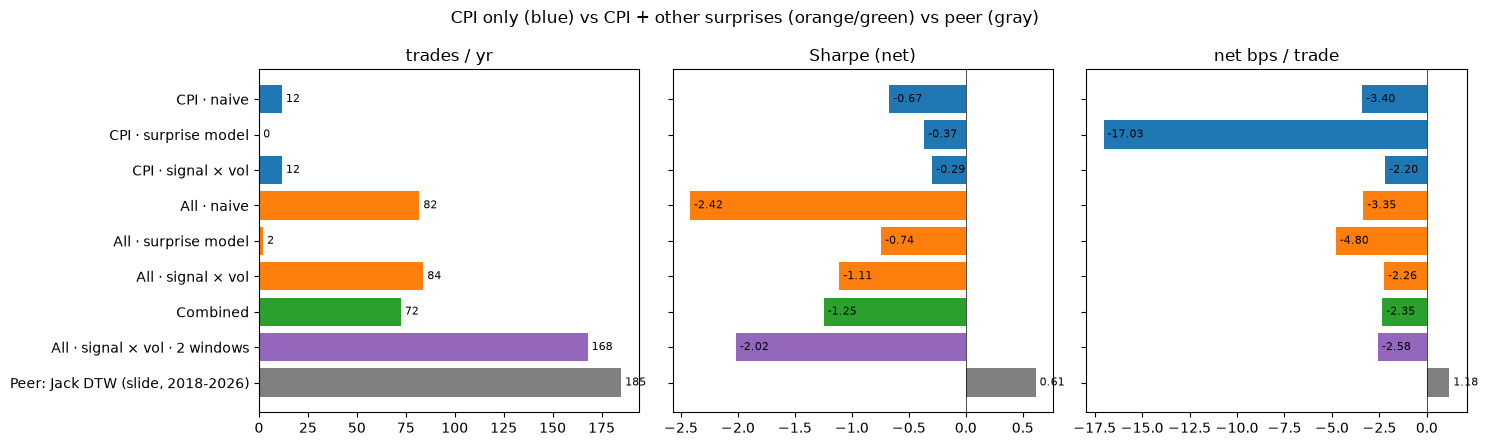

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lab = [s.replace(" (CPI model + others × vol)", "") for s in final.index]
for ax, col in zip(axes, ["trades / yr", "Sharpe (net)", "net bps / trade"]):
    vals = final[col].values
    ax.barh(lab, vals, color=["C0"] * 3 + ["C1"] * 3 + ["C2", "C4", "gray"])
    ax.axvline(0, c="k", lw=0.5); ax.set_title(col); ax.invert_yaxis()
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax.text(v, i, f" {v:.2f}" if col != "trades / yr" else f" {v:.0f}", va="center", fontsize=8)
    if ax is not axes[0]:
        ax.set_yticklabels([])
plt.suptitle("CPI only (blue) vs CPI + other surprises (orange/green) vs peer (gray)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_final_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### 10.1 Automatic summary

In [19]:
def line(s):
    r = final.loc[s]
    return (f"{s:<40s} {r['trades / yr']:6.0f} trades/yr | Sharpe {r['Sharpe (net)']:5.2f} | "
            f"{r['net bps / trade']:6.2f} bps/trade | total {r['total net P&L %']:6.2f}% | "
            f"maxDD {r['max DD %']:6.2f}% | ex-2022 Sharpe {r['Sharpe ex-2022']:5.2f} | P(random) {r['P(random sign ≥)']:.3f}")
print("=" * 120)
print(f"NOTEBOOK 05 SUMMARY — {MARKET}, 2019-2026, net of costs")
print("=" * 120)
print("CPI only:")
for s in FINAL[:3]: print("  " + line(s))
print("CPI + other surprises:")
for s in FINAL[3:]: print("  " + line(s))
print(f"\nPeer (Jack DTW slide): 185 trades/yr | Sharpe 0.61 | 1.18 bps/trade | total 18.6% | maxDD -4.9%")
best = final.drop(index=final.index[-1])["Sharpe (net)"].idxmax()
print(f"\nHighest net Sharpe: {best}")
print(f"Families admitted at least once: {', '.join(sorted(admitted_any.index))}")

NOTEBOOK 05 SUMMARY — ZN, 2019-2026, net of costs
CPI only:
  CPI · naive                                  12 trades/yr | Sharpe -0.67 |  -3.40 bps/trade | total  -2.99% | maxDD  -3.03% | ex-2022 Sharpe -1.08 | P(random) 0.580
  CPI · surprise model                          0 trades/yr | Sharpe -0.37 | -17.03 bps/trade | total  -0.17% | maxDD  -0.17% | ex-2022 Sharpe -0.39 | P(random) 1.000
  CPI · signal × vol                           12 trades/yr | Sharpe -0.29 |  -2.20 bps/trade | total  -1.93% | maxDD  -2.60% | ex-2022 Sharpe -1.19 | P(random) 0.334
CPI + other surprises:
  All · naive                                  82 trades/yr | Sharpe -2.42 |  -3.35 bps/trade | total -20.54% | maxDD -20.56% | ex-2022 Sharpe -2.53 | P(random) 0.812
  All · surprise model                          2 trades/yr | Sharpe -0.74 |  -4.80 bps/trade | total  -0.77% | maxDD  -0.87% | ex-2022 Sharpe -0.80 | P(random) 0.818
  All · signal × vol                           84 trades/yr | Sharpe -1.11 |  -2.2

## 11. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Trade count.** How many trades a year does CPI + other surprises give, compared with CPI only (about 7–11) and the peer strategy (185)?

**2. Edge per trade.** Does net bps per trade stay above the cost when weaker releases are added? Which families earn money (Section 9.2), and which only add costs?

**3. Risk-adjusted return.** Compare the Sharpe of CPI only, All, and Combined. Is the difference robust? Check `P(random sign ≥)`, the Sharpe excluding 2022, and the two sub-periods.

**4. Sizing.** Does Jack's signal × volatility sizing improve the multi-release book, as it did in his split test?

**5. Second window.** Does a second 30-minute trade after each release add profit, or only trades?

**6. Recommendation.** CPI only, CPI + others, or the combined book, and why.

# 12. Purpose, Research Questions, Answers, and Conclusion (ZN)

## Purpose of Notebook 05b (ZN)

Notebook 04b showed that ZN prices CPI surprises almost entirely in the first minute, so the CPI strategy does not cover ZN's cost of about 3 bps per round trip.

Notebook 05b repeats Notebook 05 on ZN and asks:

> **Can trading the surprises of many releases, not only CPI, give a profitable ZN book?**

**Design (identical to Notebook 05):** entry at T+1, exit 30 minutes after the release, walk-forward over **2019–2026**. The impact screen and line signs are estimated **on ZN's own reactions**, so each line's sign reflects what is good news for **bond prices**. Costs are 2 ticks + $4.50 per round trip on ZN, about **3 bps** (ES: 1.7, NQ: 0.8).

---

## Research Questions and Answers

### Sections 2–3: Releases and surprises
**Answer:** Identical to ES: 75 release families and 17,328 causal surprises (0.47% capped at ±5σ).

### Section 5: Does Notebook 05b reproduce Notebook 04b?
**Answer:** **Yes.** On all 86 CPI releases the 30-minute trade return matches Notebook 04b (maximum difference 3.6×10⁻¹⁵ bps).

### Section 6: Which releases does ZN react to?
**Question:** Which families move ZN more than other releases at the same clock time?

**Answer:** The bond screen differs from equities. The **FOMC decision ranks 1st every year from 2020**, which is natural for a rates market, but it has almost no surprise to trade. The **Employment Report** ranks 1st–3rd and **CPI** 2nd–6th. **ISM Services**, **ISM Manufacturing** and the **S&P Global PMIs** are regularly admitted. **Retail Sales** falls from 2nd (2019) to 14th (2026).

### Section 7: Is the direction signal sensible?
**Question:** With each line signed by its historical jump reaction on ZN, does the signal relate to ZN's reaction out of sample?

**Answer:** Yes. The correlation between the signal and the instant jump in 2019–2026 is **+0.56 for CPI**, +0.81 for JOLTS, +0.52 for ISM Services, +0.46 for ISM New Orders and +0.38 for ISM Manufacturing. All CPI lines are correctly signed: a hot print pushes ZN down. The Employment Report signal is weak (+0.05): the family mixes payrolls, unemployment and wages, which can push bonds in opposite directions.

### Section 9.1: How many trades, and how profitable?

| Strategy | Trades / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|
| CPI · naive | 12 | −3.4 | −3.0% | −0.67 | −3.0% |
| CPI · surprise model | 0.1 (1 trade) | −17.0 | −0.2% | −0.37 | −0.2% |
| CPI · signal × vol | 12 | −2.2 | −1.9% | −0.29 | −2.6% |
| All · naive | 82 | −3.4 | **−20.5%** | **−2.42** | −20.6% |
| All · surprise model | 2 | −4.8 | −0.8% | −0.74 | −0.9% |
| All · signal × vol | 84 | −2.3 | −14.2% | −1.11 | −14.1% |
| Combined (CPI model + others × vol) | 72 | −2.4 | −12.8% | −1.25 | −12.9% |
| All · signal × vol · 2 windows | 168 | −2.6 | −32.5% | −2.02 | −32.5% |

Every ZN strategy loses money after costs. The surprise models trade almost never, because their predicted move rarely exceeds the 3 bps cost.

### Section 9.2: Which releases earn money?
**Answer:** **None, after costs.** Every family with more than 4 trades has negative net P&L. The largest losses are the Employment Report (−4.9%), Retail Sales (−4.5%), CPI (−3.0%), Durable Goods (−2.1%) and ISM Manufacturing (−2.0%). Losses are significant for Durable Goods (t = −4.6) and Retail Sales (t = −4.1). Each loses about the cost on every trade.

### Section 9.4: Is the edge robust?

| Strategy | Sharpe 2019–21 | Sharpe 2022–26 | Sharpe ex-2022 | Random-sign p |
|---|---|---|---|---|
| CPI · naive | −1.78 | −0.51 | −1.08 | 0.58 |
| CPI · signal × vol | −1.52 | 0.02 | −1.19 | 0.33 |
| All · naive | −3.36 | −2.17 | −2.53 | 0.81 |
| All · signal × vol | −2.15 | −0.65 | −1.50 | 0.25 |

No strategy beats random directions (all p ≥ 0.25). On ZN the surprise direction adds **nothing measurable** over the 30-minute window.

### Section 9.5: How sensitive is it to costs?

| Round-trip slippage | 0 ticks | 1 | 2 (base) | 4 |
|---|---|---|---|---|
| All · naive | −0.56 | −1.49 | −2.42 | −4.24 |
| All · signal × vol | 0.08 | −0.52 | −1.11 | −2.19 |
| CPI · surprise model | 0.05 | −0.18 | −0.37 | 0.00 |

Even with **no slippage** (commission only), the multi-release naive book loses money (Sharpe −0.56). The problem on ZN is not only the cost: across the broad universe, the surprise has **no directional information** after the first minute.

### Section 9.6: Is it market-neutral?
**Answer:** Yes. Beta to buy-and-hold ZN is between −0.002 and +0.012, and time in market is below 1.5%.

---

## Final Comparison: CPI Only vs CPI + Other Surprises (ZN)

| | **CPI only** (signal × vol) | **CPI + other surprises** (All · naive) |
|---|---|---|
| Trades per year | 12 | 82 |
| Net bps per trade | −2.2 | −3.4 |
| Total net P&L (2019–26) | −1.9% | −20.5% |
| Net Sharpe | −0.29 | −2.42 |
| Sharpe with no slippage | — | −0.56 |
| Random-sign p | 0.33 | 0.81 |

---

## Conclusion

**1. There is no macro-surprise book on ZN.** Every strategy loses money after costs, from −0.3 (CPI · signal × vol) to −2.4 (All · naive).

**2. Adding releases makes it worse, not better.** On ES and NQ, adding about 10 releases diversified a small edge. On ZN it multiplies a **cost of about 3 bps per trade** by about 80 trades a year, with no edge to pay for it.

**3. The direction is right for the jump, but not for the drift.** The signs are economically correct: a hot CPI print lowers ZN, and the correlation with the instant jump is +0.56. But the bond market prices the surprise in the first minute, so the 30-minute trade that follows has no directional information (random-sign p ≥ 0.25). The book loses even with zero slippage.

**4. More trades are not available either.** The two-window book (168 trades a year) has a Sharpe of −2.0.

**Recommendation:** **do not trade macro surprises on ZN** at an executable entry. ZN can only enter the project as a **risk-diversifying market** if a signal with a real drift edge is found; the surprise is not that signal.

> **Overall:** on ZN, trading the macro surprise across about 10 releases gives ~82 trades a year but a net Sharpe of −2.4. The bond market's reaction is essentially complete within the first minute, and at about 3 bps per round trip nothing tradeable remains.